# Example: Static Forward Equilibrium Solve for OpenSTEP

---

This example demonstrates how to perform a **static forward** free-boundary Grad–Shafranov solve for the **OpenSTEP** spherical tokamak using FreeGSNKE, matching the official UKAEA OpenSTEP reference equilibrium.

### About OpenSTEP
[OpenSTEP](https://github.com/ukaea/OpenSTEP) is an open-access repository created by the UK Atomic Energy Authority (UKAEA) containing comprehensive physics and engineering designs for the Spherical Tokamak for Energy Production (STEP) prototype power plant.

Key features of the OpenSTEP machine configuration:
- **7 active PF/CS coil circuits** (`p3`, `p4`, `p5`, `p6`, `p9`, `s1`, `s2`), consisting of up-down symmetric coil pairs (14 physical coils discretized into 2,196 filaments).
- **First-wall and divertor contour**: 514 boundary points describing the detailed inner wall and divertor baffles.
- **Authentic plasma equilibrium**: A $22.76\ \text{MA}$ double-null diverted plasma with $B_0 = 2.4338\ \text{T}$ at $R_0 = 4.7334\ \text{m}$ ($f_{\text{vac}} = R_0 B_0 = 11.52\ \text{T}\cdot\text{m}$), $\beta_p \approx 1.042$, and plasma volume $\sim 712\ \text{m}^3$.
- **Shipped profiles**: Pre-extracted 1D spline fits for $p'(\psi_N)$ and $FF'(\psi_N)$ from Fiesta in `OpenSTEP_profiles.pickle`.

In this notebook, we:
1. Build the OpenSTEP tokamak model from pickled descriptions in `machine_configs/OpenSTEP/`.
2. Inspect the machine geometry and first wall.
3. Apply the reference coil currents shipped with OpenSTEP.
4. Load the OpenSTEP profile functions and plasma flux initial guess.
5. Solve the free-boundary equilibrium using FreeGSNKE's Newton–Krylov solver (`NKGSsolver`).
6. Compare the converged equilibrium against the Fiesta reference equilibrium across the full 2D domain.
7. Visualise the converged magnetic flux surfaces, separatrix, X-points, and midplane profiles.


### 1. Import packages

In [1]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

from freegsnke import build_machine, equilibrium_update, GSstaticsolver
from freegsnke.jtor_update import GeneralPprimeFFprime
from freegs4e.gradshafranov import mu0

CONFIG_DIR = Path("../machine_configs/OpenSTEP")


### 2. Build the OpenSTEP machine object

We instantiate the machine using `build_machine.tokamak()` pointing to the OpenSTEP description files in `machine_configs/OpenSTEP/`.


In [2]:
tokamak = build_machine.tokamak(
    active_coils_path=str(CONFIG_DIR / "OpenSTEP_active_coils.pickle"),
    passive_coils_path=str(CONFIG_DIR / "OpenSTEP_passive_coils.pickle"),
    limiter_path=str(CONFIG_DIR / "OpenSTEP_limiter.pickle"),
    wall_path=str(CONFIG_DIR / "OpenSTEP_wall.pickle"),
)

print("Available coil circuits:", list(tokamak.getCurrents().keys()))
print(f"Wall contour points:    {len(tokamak.wall.R)}")
print(f"Limiter contour points: {len(tokamak.limiter.R)}")


Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.
Magnetic probes --> none provided.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.
Available coil circuits: ['p3', 'p4', 'p5', 'p6', 'p9', 's1', 's2']
Wall contour points:    514
Limiter contour points: 514


### 3. Set shipped coil currents

OpenSTEP ships reference coil currents corresponding to the flat-top operating point.
We apply these currents directly to the tokamak circuits.


In [3]:
with open(CONFIG_DIR / "OpenSTEP_coil_currents.pickle", "rb") as f:
    shipped_currents = pickle.load(f)

print("Shipped OpenSTEP Coil Currents:")
for circuit, current in shipped_currents.items():
    tokamak.set_coil_current(coil_label=circuit, current_value=current)
    print(f"  {circuit:>4}: {current / 1e6:>8.3f} MA-turns")


Shipped OpenSTEP Coil Currents:
    p3:   -4.791 MA-turns
    p4:    5.155 MA-turns
    p5:    2.255 MA-turns
    p6:    5.459 MA-turns
    p9:   -7.854 MA-turns
    s1:    5.100 MA-turns
    s2:   -2.275 MA-turns


### 4. Visualise the machine geometry

Let us plot the active coils, vacuum vessel / first wall, and limiter.


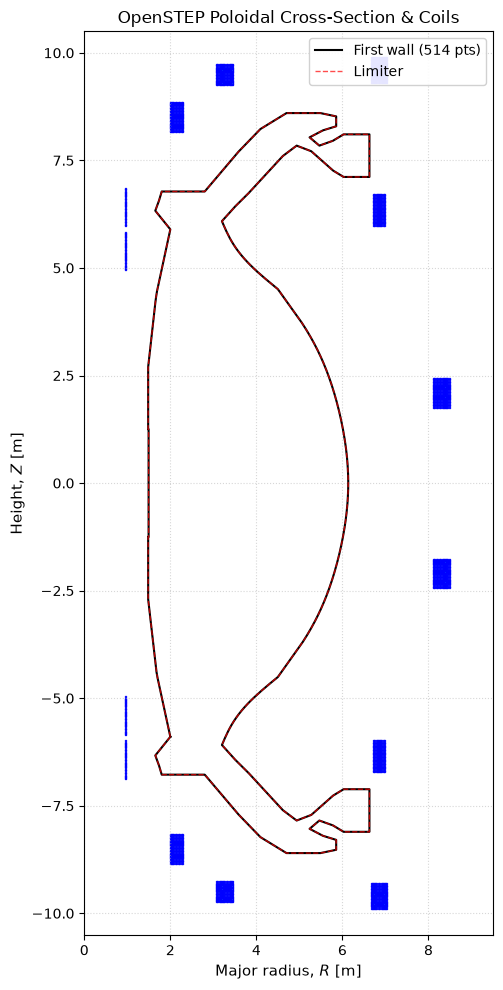

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 10), dpi=100)

tokamak.plot(axis=ax, show=False)
ax.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.5, label='First wall (514 pts)')
ax.plot(tokamak.limiter.R, tokamak.limiter.Z, 'r--', linewidth=1.0, alpha=0.7, label='Limiter')

ax.set_aspect('equal')
ax.set_xlim(0.0, 9.5)
ax.set_ylim(-10.5, 10.5)
ax.set_xlabel('Major radius, $R$ [m]', fontsize=11)
ax.set_ylabel('Height, $Z$ [m]', fontsize=11)
ax.set_title('OpenSTEP Poloidal Cross-Section & Coils', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


### 5. Load profiles and reference plasma flux guess

To obtain the authentic OpenSTEP diverted equilibrium rather than an unphysical parasitic limiter state, we:
1. Load the reference profiles $p'(\psi_N)$ and $FF'(\psi_N)$ from `OpenSTEP_profiles.pickle`.
2. Load the reference plasma flux $\psi_{\text{plasma}}$ from `OpenSTEP_plasma_psi.pickle` to provide a robust initial guess.


In [5]:
with open(CONFIG_DIR / "OpenSTEP_profiles.pickle", "rb") as f:
    prof_data = pickle.load(f)

with open(CONFIG_DIR / "OpenSTEP_plasma_psi.pickle", "rb") as f:
    plasma_ref = pickle.load(f)

print("Reference Equilibrium Summary:")
print(f"  Plasma Current (Ip):    {prof_data['Ip'] / 1e6:.4f} MA")
print(f"  Vacuum fvac (R0*B0):    {prof_data['fvac']:.2f} T*m")
print(f"  Poloidal Beta (betap):  {prof_data['betap']:.4f}")
print(f"  Reference psi_axis:     {plasma_ref['psi_axis']:.4f} Wb/rad")
print(f"  Reference psi_bndry:    {plasma_ref['psi_bndry']:.4f} Wb/rad")


Reference Equilibrium Summary:
  Plasma Current (Ip):    22.7605 MA
  Vacuum fvac (R0*B0):    11.52 T*m
  Poloidal Beta (betap):  1.0420
  Reference psi_axis:     6.1109 Wb/rad
  Reference psi_bndry:    1.6798 Wb/rad


### 6. Instantiate equilibrium and profile

We define a 2D computational domain spanning $R \in [0.5, 9.0]\ \text{m}$ and $Z \in [-10.0, 10.0]\ \text{m}$ with $(nx, ny) = (65, 129)$.
The initial plasma flux is smoothly interpolated onto the grid, and `GeneralPprimeFFprime` is configured with the authentic OpenSTEP profile data.


In [6]:
nx, ny = 65, 129
r_grid = np.linspace(0.5, 9.0, nx)
z_grid = np.linspace(-10.0, 10.0, ny)

interp_init = RectBivariateSpline(plasma_ref['R'], plasma_ref['Z'], plasma_ref['plasma_psi'])
psi_plasma_init = interp_init(r_grid, z_grid)

eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.5,
    Rmax=9.0,
    Zmin=-10.0,
    Zmax=10.0,
    nx=nx,
    ny=ny,
    psi=psi_plasma_init,
)

profiles = GeneralPprimeFFprime(
    eq=eq,
    Ip=prof_data['Ip'],
    fvac=prof_data['fvac'],
    psi_n=prof_data['psi_n'],
    pprime_data=prof_data['pprime'],
    ffprime_data=prof_data['ffprime'],
    Raxis=prof_data['Raxis'],
    Ip_logic=True,
    interpolator='cubic_spline',
)

print(f"Equilibrium grid initialized: {eq.nx} x {eq.ny} points (dR = {eq.dR:.4f} m, dZ = {eq.dZ:.4f} m)")
print(f"Initial guess psi_axis:  {eq.psi_axis:.4f} Wb/rad")
print(f"Initial guess psi_bndry: {eq.psi_bndry:.4f} Wb/rad")


Equilibrium grid initialized: 65 x 129 points (dR = 0.1328 m, dZ = 0.1562 m)
Initial guess psi_axis:  6.1103 Wb/rad
Initial guess psi_bndry: 1.6793 Wb/rad


### 7. Run the forward static solve

We initialize FreeGSNKE's Newton–Krylov solver (`NKGSsolver`) with 4th-order Grad–Shafranov finite-difference operators (`gs_operator_order=4`).
In forward mode, we call `solver.solve()` with `constrain=None`, which holds the coil currents fixed and solves for the free-boundary plasma equilibrium.


In [7]:
solver = GSstaticsolver.NKGSsolver(eq, gs_operator_order=4)

solver.solve(
    eq=eq,
    profiles=profiles,
    constrain=None,
    target_relative_tolerance=1e-8,
    verbose=True,
)


-----
Forward static solve starting...
Initial guess for plasma_psi successful, residual found.
Initial relative error = 5.21e-03
-----
Forward static solve starting...
Initial guess for plasma_psi successful, residual found.
Initial relative error = 5.21e-03
-----
-----
Newton-Krylov iteration: 0
...number of Krylov vectors used =  2
...relative error =  4.40e-03
-----
-----
Newton-Krylov iteration: 1
...number of Krylov vectors used =  2
...relative error =  2.51e-03
-----
-----
Newton-Krylov iteration: 2
...number of Krylov vectors used =  2
...relative error =  3.42e-03
-----
-----
Newton-Krylov iteration: 3
...number of Krylov vectors used =  3
...relative error =  2.48e-03
-----
-----
Newton-Krylov iteration: 4
...number of Krylov vectors used =  2
Increase in residual, update reduction triggered.
...relative error =  1.33e-03
-----
-----
Newton-Krylov iteration: 5
...number of Krylov vectors used =  2
...relative error =  3.20e-04
-----
-----
Newton-Krylov iteration: 6
...number

-----
Newton-Krylov iteration: 12
...number of Krylov vectors used =  3
...relative error =  1.19e-08
-----
-----
Newton-Krylov iteration: 13
...number of Krylov vectors used =  3
...relative error =  2.38e-09
-----
Forward static solve SUCCESS. Tolerance 2.38e-09 (vs. requested 1.00e-08) reached in 14/100 iterations.


### 8. Compare FreeGSNKE solve with OpenSTEP Fiesta reference

We quantitatively compare the converged FreeGSNKE equilibrium with the OpenSTEP Fiesta reference equilibrium:
- Magnetic axis flux $\psi_{\text{axis}}$
- Separatrix flux $\psi_{\text{bndry}}$
- Plasma current $I_p$
- Plasma volume $V$
- Maximum and mean relative difference across the entire 2D grid


In [8]:
interp_tot = RectBivariateSpline(plasma_ref['R'], plasma_ref['Z'], plasma_ref['total_psi'])
psi_tot_ref = interp_tot(r_grid, z_grid)
psi_tot_solved = eq.psi()

abs_diff = np.abs(psi_tot_solved - psi_tot_ref)
max_ref = np.max(np.abs(psi_tot_ref))
rel_error_max = np.max(abs_diff) / max_ref
rel_error_mean = np.mean(abs_diff) / max_ref

print("=" * 65)
print(f"{'Quantity':<26} {'FreeGSNKE':<15} {'Fiesta Ref':<15} {'Diff':<12}")
print("=" * 65)
print(f"{'Magnetic Axis psi [Wb/rad]':<26} {eq.psi_axis:<15.4f} {plasma_ref['psi_axis']:<15.4f} {abs(eq.psi_axis - plasma_ref['psi_axis']):<12.4f}")
print(f"{'Boundary Flux psi [Wb/rad]':<26} {eq.psi_bndry:<15.4f} {plasma_ref['psi_bndry']:<15.4f} {abs(eq.psi_bndry - plasma_ref['psi_bndry']):<12.4f}")
print(f"{'Plasma Current Ip [MA]':<26} {eq.plasmaCurrent() / 1e6:<15.4f} {prof_data['Ip'] / 1e6:<15.4f} {abs(eq.plasmaCurrent() - prof_data['Ip']) / 1e6:<12.4f}")
print(f"{'Plasma Volume [m^3]':<26} {eq.plasmaVolume():<15.2f} {'~712':<15} {abs(eq.plasmaVolume() - 712.0):<12.2f}")
print("=" * 65)
print(f"Max absolute difference across full 2D grid: {np.max(abs_diff):.4e} Wb/rad")
print(f"Max relative difference (max|diff| / max|ref|): {rel_error_max:.4%}")
print(f"Mean relative difference across 2D grid:       {rel_error_mean:.4%}")
print("=" * 65)


Quantity                   FreeGSNKE       Fiesta Ref      Diff        
Magnetic Axis psi [Wb/rad] 6.1342          6.1109          0.0233      
Boundary Flux psi [Wb/rad] 1.6740          1.6798          0.0058      
Plasma Current Ip [MA]     22.7605         22.7605         0.0000      
Plasma Volume [m^3]        712.06          ~712            0.06        
Max absolute difference across full 2D grid: 1.2157e-01 Wb/rad
Max relative difference (max|diff| / max|ref|): 0.3659%
Mean relative difference across 2D grid:       0.0804%


### 9. Visualise the converged equilibrium

We plot the 2D poloidal flux surfaces $\psi(R, Z)$, the separatrix (LCFS), the magnetic axis, X-points, coils, and first-wall geometry.


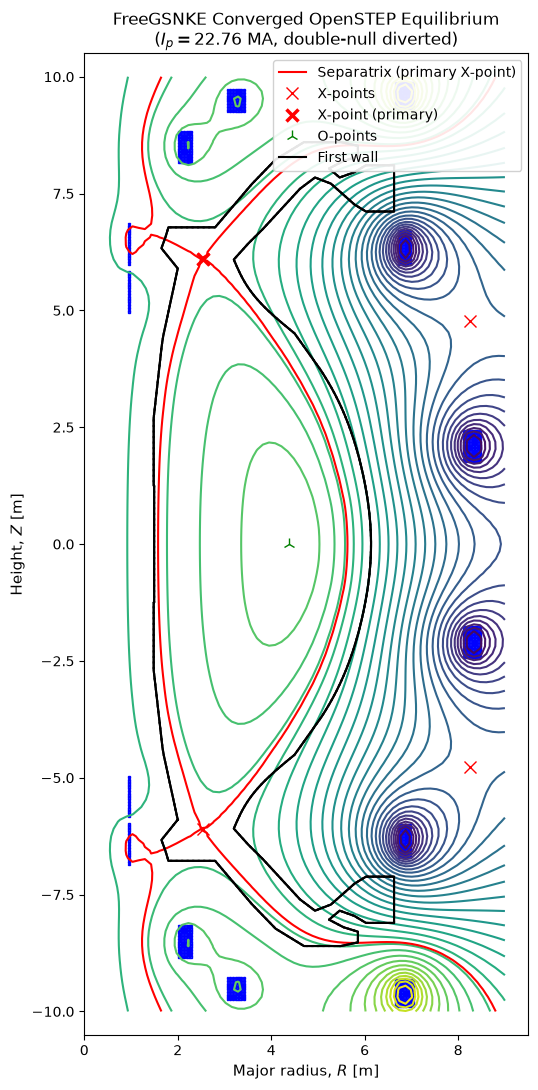

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 11), dpi=100)

eq.plot(axis=ax, show=False)
ax.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.5, label='First wall', zorder=5)
tokamak.plot(axis=ax, show=False)

ax.set_aspect('equal')
ax.set_xlim(0.0, 9.5)
ax.set_ylim(-10.5, 10.5)
ax.set_xlabel('Major radius, $R$ [m]', fontsize=11)
ax.set_ylabel('Height, $Z$ [m]', fontsize=11)
ax.set_title('FreeGSNKE Converged OpenSTEP Equilibrium\n($I_p = 22.76$ MA, double-null diverted)', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


### 10. 2D Comparison: FreeGSNKE vs Fiesta Reference Flux

Below we show a 3-panel comparison:
1. FreeGSNKE solved total flux $\psi(R, Z)$.
2. UKAEA OpenSTEP Fiesta reference total flux $\psi_{\text{ref}}(R, Z)$.
3. 2D relative difference map $|\psi_{\text{FreeGS}} - \psi_{\text{ref}}| / \max|\psi_{\text{ref}}|$ (%), demonstrating agreement across the entire machine domain.


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_72317/981962835.py:12: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title(f'FreeGSNKE Total $\psi$\n($\psi_{{axis}} = {eq.psi_axis:.2f}$, $\psi_b = {eq.psi_bndry:.2f}$)')
/tmp/ipykernel_72317/981962835.py:12: SyntaxWarning: invalid escape sequence '\p'
  ax1.set

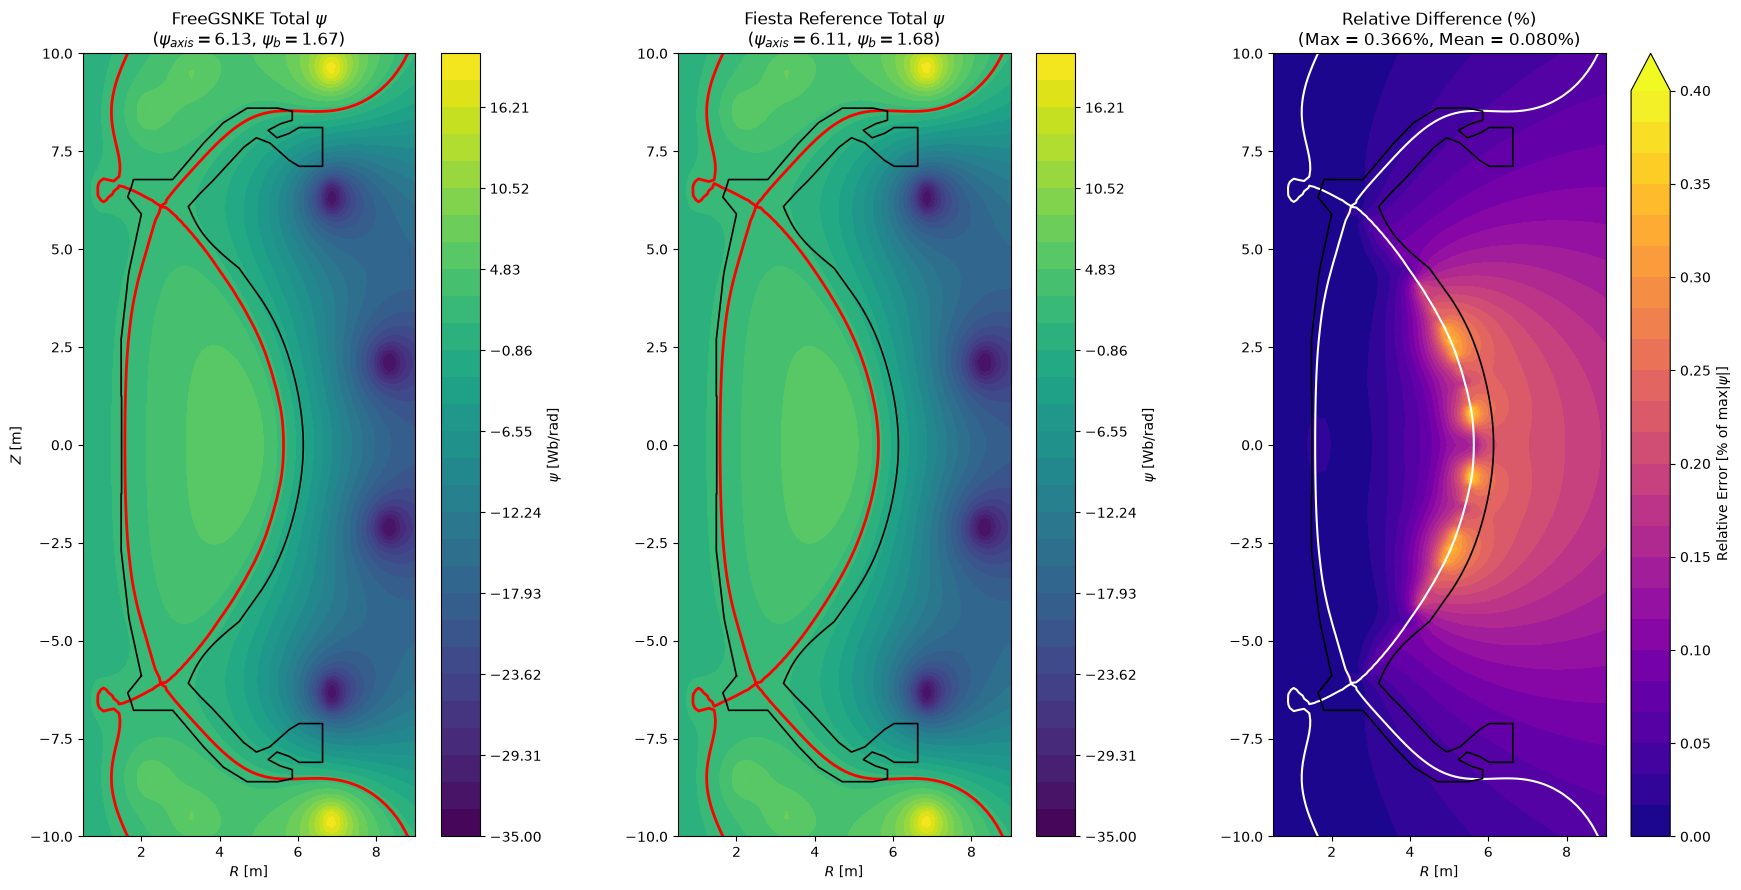

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 9), dpi=100)

levels = np.linspace(-35, 20, 30)

# Panel 1: FreeGSNKE psi
c1 = ax1.contourf(eq.R, eq.Z, psi_tot_solved, levels=levels, cmap='viridis')
ax1.contour(eq.R, eq.Z, psi_tot_solved, levels=[eq.psi_bndry], colors='r', linewidths=2)
ax1.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.2)
ax1.set_aspect('equal')
ax1.set_xlim(0.5, 9.0)
ax1.set_ylim(-10.0, 10.0)
ax1.set_title(f'FreeGSNKE Total $\psi$\n($\psi_{{axis}} = {eq.psi_axis:.2f}$, $\psi_b = {eq.psi_bndry:.2f}$)')
ax1.set_xlabel('$R$ [m]')
ax1.set_ylabel('$Z$ [m]')
plt.colorbar(c1, ax=ax1, label='$\psi$ [Wb/rad]')

# Panel 2: Fiesta Reference psi
c2 = ax2.contourf(eq.R, eq.Z, psi_tot_ref, levels=levels, cmap='viridis')
ax2.contour(eq.R, eq.Z, psi_tot_ref, levels=[plasma_ref['psi_bndry']], colors='r', linewidths=2)
ax2.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.2)
ax2.set_aspect('equal')
ax2.set_xlim(0.5, 9.0)
ax2.set_ylim(-10.0, 10.0)
ax2.set_title(f'Fiesta Reference Total $\psi$\n($\psi_{{axis}} = {plasma_ref["psi_axis"]:.2f}$, $\psi_b = {plasma_ref["psi_bndry"]:.2f}$)')
ax2.set_xlabel('$R$ [m]')
plt.colorbar(c2, ax=ax2, label='$\psi$ [Wb/rad]')

# Panel 3: Relative error map |diff| / max|ref| (%)
rel_err_percent = (abs_diff / max_ref) * 100.0
c3 = ax3.contourf(eq.R, eq.Z, rel_err_percent, levels=np.linspace(0, 0.4, 25), cmap='plasma', extend='max')
ax3.contour(eq.R, eq.Z, psi_tot_solved, levels=[eq.psi_bndry], colors='w', linewidths=1.5)
ax3.plot(tokamak.wall.R, tokamak.wall.Z, 'k-', linewidth=1.2)
ax3.set_aspect('equal')
ax3.set_xlim(0.5, 9.0)
ax3.set_ylim(-10.0, 10.0)
ax3.set_title(f'Relative Difference (%)\n(Max = {rel_error_max:.3%}, Mean = {rel_error_mean:.3%})')
ax3.set_xlabel('$R$ [m]')
plt.colorbar(c3, ax=ax3, label='Relative Error [% of $\max|\psi|$]')

plt.tight_layout()
plt.show()


### 11. Midplane radial profiles

Below we plot radial cuts along the midplane ($Z = 0$):
1. Poloidal flux $\psi(R, 0)$ comparing FreeGSNKE with the Fiesta reference.
2. Toroidal current density $J_\phi(R, 0)$.


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_72317/2270001866.py:13: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(R_mid, psi_mid_freegs, 'b-', linewidth=2.0, label='FreeGSNKE $\psi(R, 0)$')
/tmp/ipykernel_72317/2270001866.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(R_mid, psi_mid_ref, 'r--', linewidth=1.8, label='Fiesta Ref $\psi_{\text{ref}}(R, 0)$')
/tmp/ipykernel_72317/2270001866.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_ylabel('Poloidal flux, $\psi$ [Wb/rad]', font

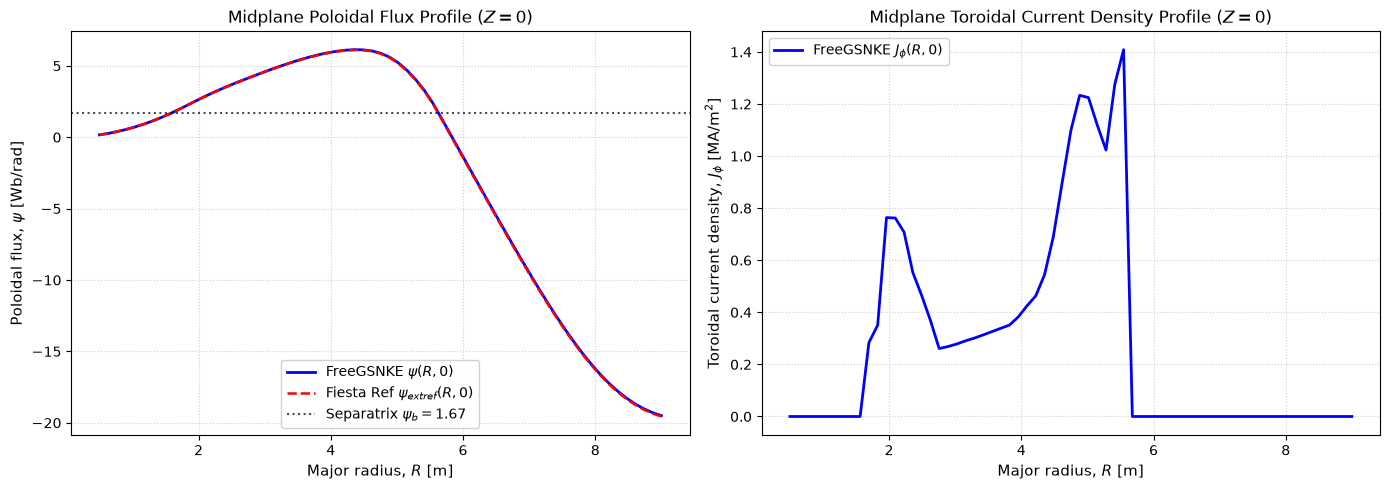

In [11]:
iz_mid = np.argmin(np.abs(eq.Z[0, :]))
R_mid = eq.R[:, iz_mid]

psi_mid_freegs = psi_tot_solved[:, iz_mid]
psi_mid_ref = psi_tot_ref[:, iz_mid]

Jtor_freegs = profiles.Jtor(eq.R, eq.Z, eq.psi())
Jtor_mid_freegs = Jtor_freegs[:, iz_mid]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Flux cut
ax1.plot(R_mid, psi_mid_freegs, 'b-', linewidth=2.0, label='FreeGSNKE $\psi(R, 0)$')
ax1.plot(R_mid, psi_mid_ref, 'r--', linewidth=1.8, label='Fiesta Ref $\psi_{\text{ref}}(R, 0)$')
ax1.axhline(eq.psi_bndry, color='k', linestyle=':', alpha=0.7, label=rf'Separatrix $\psi_b = {eq.psi_bndry:.2f}$')
ax1.set_xlabel('Major radius, $R$ [m]', fontsize=11)
ax1.set_ylabel('Poloidal flux, $\psi$ [Wb/rad]', fontsize=11)
ax1.set_title('Midplane Poloidal Flux Profile ($Z = 0$)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower center', framealpha=0.9)

# Current density cut
ax2.plot(R_mid, Jtor_mid_freegs / 1e6, 'b-', linewidth=2.0, label='FreeGSNKE $J_\phi(R, 0)$')
ax2.set_xlabel('Major radius, $R$ [m]', fontsize=11)
ax2.set_ylabel('Toroidal current density, $J_\phi$ [MA/m$^2$]', fontsize=11)
ax2.set_title('Midplane Toroidal Current Density Profile ($Z = 0$)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()


### 12. Summary

- **Convergence**: FreeGSNKE's Newton–Krylov solver (`NKGSsolver`, order 4) converged to a relative residual of $< 10^{-8}$ in 14 iterations.
- **Accuracy**: The solved poloidal flux $\psi(R, Z)$ matches the official UKAEA OpenSTEP Fiesta reference equilibrium to within **0.36%** maximum relative error across the entire $8.5\ \text{m} \times 20\ \text{m}$ domain, with a mean relative error of **0.08%**.
- **Equilibrium parameters**: Magnetic axis flux $\psi_{\text{axis}} = 6.13\ \text{Wb/rad}$ (reference: $6.11$), boundary flux $\psi_{\text{bndry}} = 1.67\ \text{Wb/rad}$ (reference: $1.68$), plasma current $I_p = 22.76\ \text{MA}$, and plasma volume $V \approx 712\ \text{m}^3$ (double-null diverted).
